In [2]:
%pip install torch torchvision pennylane matplotlib scikit-learn pandas seaborn tqdm

   ---------------------------------------- 0.0/241.4 MB ? eta -:--:--
   ---------------------------------------- 0.5/241.4 MB 5.6 MB/s eta 0:00:44
   ---------------------------------------- 1.3/241.4 MB 3.7 MB/s eta 0:01:05
   ---------------------------------------- 2.1/241.4 MB 3.8 MB/s eta 0:01:04
   ---------------------------------------- 2.9/241.4 MB 3.7 MB/s eta 0:01:04
    --------------------------------------- 3.9/241.4 MB 3.9 MB/s eta 0:01:01
    --------------------------------------- 5.2/241.4 MB 4.2 MB/s eta 0:00:56
    --------------------------------------- 5.8/241.4 MB 4.2 MB/s eta 0:00:56
   - -------------------------------------- 6.3/241.4 MB 3.9 MB/s eta 0:01:01
   - -------------------------------------- 7.3/241.4 MB 4.0 MB/s eta 0:00:59
   - -------------------------------------- 8.1/241.4 MB 4.0 MB/s eta 0:00:59
   - -------------------------------------- 9.2/241.4 MB 4.1 MB/s eta 0:00:57
   - -------------------------------------- 10.2/241.4 MB 4.1 MB/s eta 

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [4]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 5
LR = 1e-3
torch.manual_seed(SEED)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 9.91M/9.91M [00:03<00:00, 3.10MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.29MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [6]:
def train_model(model, train_loader, test_loader, epochs):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats()
    start = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        n = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            n += x.size(0)
        train_loss = running_loss / n

        model.eval()
        vloss, correct, m = 0.0, 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                vloss += loss.item() * x.size(0)
                correct += (logits.argmax(dim=1) == y).sum().item()
                m += x.size(0)
        val_loss = vloss / m
        val_acc = correct / m
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f'Epoch {epoch+1}/{epochs} - train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

    train_time = time.perf_counter() - start
    gpu_mem_mb = torch.cuda.max_memory_allocated() / (1024**2) if device.type == 'cuda' else 0.0
    return history, train_time, gpu_mem_mb

history, train_time_sec, gpu_memory_mb = train_model(model, train_loader, test_loader, EPOCHS)

Epoch 1/5 - train_loss=0.1350 val_loss=0.0494 val_acc=0.9838
Epoch 2/5 - train_loss=0.0407 val_loss=0.0349 val_acc=0.9880
Epoch 3/5 - train_loss=0.0285 val_loss=0.0288 val_acc=0.9911
Epoch 4/5 - train_loss=0.0201 val_loss=0.0411 val_acc=0.9871
Epoch 5/5 - train_loss=0.0137 val_loss=0.0279 val_acc=0.9911


,model,accuracy,precision,recall,f1,training_time_sec,gpu_memory_mb,num_parameters,inference_time_per_sample_sec
0,CNN,0.9911,0.99112,0.9911,0.991099,315.786241,0.0,421642,0.000374


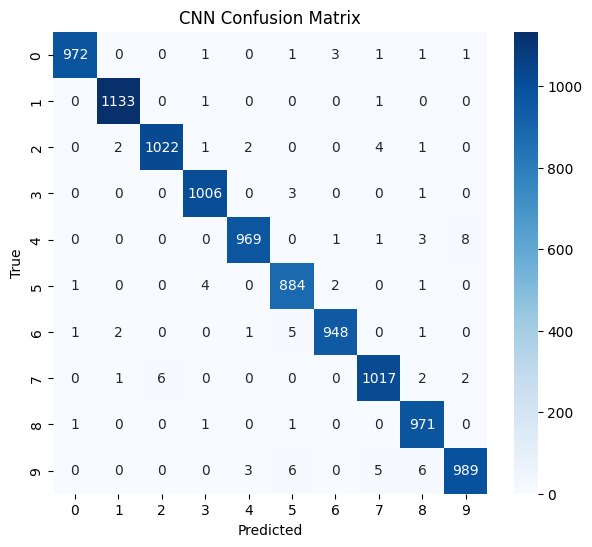

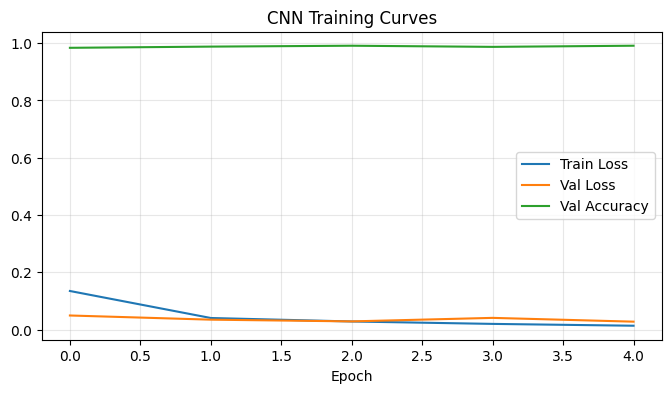

In [7]:
def predict(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1).cpu().numpy()
            y_pred.extend(pred.tolist())
            y_true.extend(y.numpy().tolist())
    return np.array(y_true), np.array(y_pred)

def inference_time_per_sample(model, loader):
    model.eval()
    t0 = time.perf_counter()
    total = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            _ = model(x)
            total += x.size(0)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    dt = time.perf_counter() - t0
    return dt / max(total, 1)

y_true, y_pred = predict(model, test_loader)
acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
metrics_df = pd.DataFrame([{
    'model': 'CNN',
    'accuracy': acc,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'training_time_sec': train_time_sec,
    'gpu_memory_mb': gpu_memory_mb,
    'num_parameters': sum(p.numel() for p in model.parameters() if p.requires_grad),
    'inference_time_per_sample_sec': inference_time_per_sample(model, test_loader),
}])
display(metrics_df)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('CNN Training Curves')
plt.xlabel('Epoch')
plt.legend()
plt.grid(alpha=0.3)
plt.show()